# Cryptocurrency Forecasting — LSTM
This notebook implements a Bidirectional Stacked LSTM (Long Short-Term Memory)
neural network to forecast the next 180 days of closing prices for 10 major
cryptocurrencies. LSTM is a deep learning architecture specifically designed
for sequential time series data, capable of learning complex non-linear
dependencies across long time horizons.

**Key Features:**
- Bidirectional Stacked LSTM architecture (128 + 64 units)
- 6 input features: Close, Volume, MA_7, MA_30, Daily_Return, Volatility_7
- 90-day lookback window for sequence learning
- Huber loss function — robust to price outliers
- EarlyStopping, ReduceLROnPlateau, ModelCheckpoint callbacks
- 70/15/15 Train/Validation/Test split
- Iterative future forecasting using last known sequence

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

os.makedirs("../data/forecasts/lstm", exist_ok=True)
os.makedirs("../models", exist_ok=True)

## Load Dataset
Load the preprocessed combined cryptocurrency dataset from `data/processed/`.

In [ ]:
df = pd.read_csv("../data/processed/combined_crypto_data.csv", parse_dates=["Date"])

print("Shape:", df.shape)
print("Cryptos:", df["Crypto"].unique())
df.head()

Shape: (18250, 14)
Cryptos: ['ADA' 'BNB' 'BTC' 'DOGE' 'DOT' 'ETH' 'LINK' 'LTC' 'SOL' 'XRP']


,Date,Open,High,Low,Close,Volume,Crypto,Daily_Return,Log_Return,Price_Range,MA_7,MA_30,Volatility_7,Cumulative_Return
0,2021-01-01,0.181382,0.184246,0.172022,0.175350,1122218004,ADA,NaN,NaN,0.012224,NaN,NaN,NaN,0.000000
1,2021-01-02,0.175359,0.184253,0.169233,0.177423,1408849504,ADA,1.182210,0.011753,0.015020,NaN,NaN,NaN,1.182210
2,2021-01-03,0.177382,0.208679,0.173376,0.204995,2303857909,ADA,15.540266,0.144449,0.035303,NaN,NaN,NaN,16.906194
3,2021-01-04,0.205236,0.239661,0.194450,0.224762,3260699086,ADA,9.642667,0.092056,0.045211,NaN,NaN,NaN,28.179070
4,2021-01-05,0.224817,0.264886,0.208454,0.258314,4097207384,ADA,14.927800,0.139134,0.056432,NaN,NaN,NaN,47.313385


## Configuration
All model hyperparameters and settings defined in one place for easy modification.

| Parameter | Value | Reasoning |
|-----------|-------|-----------|
| LOOKBACK | 90 days | 3 months of history per prediction |
| FORECAST_DAYS | 180 days | 6 months ahead forecast horizon |
| EPOCHS | 100 | Max training iterations (EarlyStopping will stop earlier) |
| BATCH_SIZE | 32 | Standard mini-batch size for stable gradient updates |
| Features | 6 | Close, Volume, MA_7, MA_30, Daily_Return, Volatility_7 |
| Target | Close | Predicting closing price |

**Why 6 features?**
Using multiple features allows the LSTM to learn relationships between
price, volume, momentum (MA), and volatility — giving it richer context
than price-only models like ARIMA and Prophet.

In [ ]:
LOOKBACK      = 90        # past days used to predict
FORECAST_DAYS = 180       # days to forecast into future
FEATURES      = ["Close", "Volume", "MA_7", "MA_30", "Daily_Return", "Volatility_7"]
TARGET        = "Close"
EPOCHS        = 100
BATCH_SIZE    = 32
output_dir    = "../data/forecasts/lstm"
models_dir    = "../models"

## Helper — Prepare Sequences
Converts a scaled time series array into supervised learning sequences
suitable for LSTM input.

**How it works:**
- For each position `i` from `lookback` to end of data:
  - **X[i]:** Last `lookback` rows of all features (shape: lookback × n_features)
  - **y[i]:** Close price at position `i` (index 0 = Close)

**Example with LOOKBACK=90:**
```
X[0] = rows[0:90]   → y[0] = Close at row 90
X[1] = rows[1:91]   → y[1] = Close at row 91
...
```
This sliding window approach creates overlapping training samples
that teach the LSTM to recognize temporal patterns.

In [ ]:
def prepare_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i])
        y.append(data[i, 0])  # index 0 = Close (target)
    return np.array(X), np.array(y)

## Helper — Prepare Data per Cryptocurrency
Prepares a complete train/validation/test dataset for a single cryptocurrency.

**Pipeline:**
1. Filter data for selected crypto
2. Drop NaN rows from rolling features (MA_7, MA_30, Volatility_7)
3. Scale all features to [0,1] using MinMaxScaler (per-crypto scaler saved)
4. Split into Train (70%) / Validation (15%) / Test (15%)
5. Create overlapping LOOKBACK sequences for each split

**Why per-crypto scaling?**
Each cryptocurrency has vastly different price ranges
(BTC at $80,000 vs DOGE at $0.30). Using a separate scaler
per crypto prevents one coin's scale from affecting another.

**Data Split:**
```
|←————— Train 70% ——————→|←— Val 15% —→|←— Test 15% —→|
```

In [ ]:
def prepare_data(df, crypto, lookback):
    crypto_df = df[df["Crypto"] == crypto][["Date"] + FEATURES].copy()
    crypto_df = crypto_df.sort_values("Date").reset_index(drop=True)

    # Drop NaN rows (from rolling features)
    crypto_df = crypto_df.dropna().reset_index(drop=True)

    dates  = crypto_df["Date"].values
    values = crypto_df[FEATURES].values

    # Scale features
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(values)

    # Train / Val / Test split (70 / 15 / 15)
    n         = len(scaled)
    train_end = int(n * 0.70)
    val_end   = int(n * 0.85)

    train = scaled[:train_end]
    val   = scaled[train_end - lookback:val_end]
    test  = scaled[val_end - lookback:]

    X_train, y_train = prepare_sequences(train, lookback)
    X_val,   y_val   = prepare_sequences(val,   lookback)
    X_test,  y_test  = prepare_sequences(test,  lookback)

    return X_train, y_train, X_val, y_val, X_test, y_test, scaler, dates, scaled

## Helper — Build Bidirectional Stacked LSTM Model
Constructs the neural network architecture.

**Architecture:**
```
Input (90 days × 6 features)
        ↓
Bidirectional LSTM (128 units, return_sequences=True)
        ↓
Dropout (0.3)
        ↓
Bidirectional LSTM (64 units)
        ↓
Dropout (0.3)
        ↓
Dense (32, ReLU)
        ↓
Dense (1) → Predicted Close Price
```

**Key Design Choices:**
| Choice | Reason |
|--------|--------|
| Bidirectional | Reads sequence forward AND backward for richer context |
| Stacked LSTM | Deeper architecture learns more complex patterns |
| Dropout (0.3) | Prevents overfitting on training data |
| Huber Loss | Less sensitive to outliers than MSE — ideal for volatile crypto |
| Adam (lr=0.001) | Adaptive learning rate for stable convergence |

In [ ]:
def build_model(lookback, n_features):
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True),
                      input_shape=(lookback, n_features)),
        Dropout(0.3),

        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.3),

        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="huber",          # huber loss is robust to outliers (better than MSE for crypto)
        metrics=["mae"]
    )
    return model

## Helper — Training Callbacks
Three callbacks control the training process:

| Callback | Purpose | Configuration |
|----------|---------|---------------|
| EarlyStopping | Stops training when val_loss stops improving | patience=15 epochs |
| ReduceLROnPlateau | Halves learning rate when val_loss plateaus | patience=7, factor=0.5 |
| ModelCheckpoint | Saves best model weights automatically | monitor val_loss |

**Why EarlyStopping?**
Prevents overfitting by stopping training before the model memorizes
the training data. `restore_best_weights=True` ensures we always
keep the best-performing checkpoint.

In [ ]:
def get_callbacks(crypto, models_dir):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=7,
            min_lr=1e-6,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f"{models_dir}/{crypto}_lstm.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=0
        )
    ]

## Helper — Evaluate Model
Computes MAE, RMSE, and MAPE on original price scale predictions.

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| MAE | mean(|actual - predicted|) | Average error in USD |
| RMSE | sqrt(mean((actual - predicted)²)) | Penalizes large errors more |
| MAPE | mean(|actual - predicted| / actual) × 100 | % error — scale independent |

MAPE is the primary comparison metric as it is scale-independent,
allowing fair comparison between BTC ($80,000) and DOGE ($0.30).

In [ ]:
def evaluate_model(actual, predicted):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {
        "MAE" : round(mae,  4),
        "RMSE": round(rmse, 4),
        "MAPE": round(mape, 4)
    }

## Helper — Inverse Transform Predictions
Converts scaled predictions back to original USD price scale.

**The challenge:**
MinMaxScaler was fitted on all 6 features together.
To inverse transform only the Close price (index 0),
a dummy array of zeros is created for the other 5 features,
the predicted value is placed at index 0, and the full
inverse transform is applied — then only column 0 is returned.

In [ ]:
def inverse_close(scaler, values):
    # Only inverse transform the Close column (index 0)
    dummy = np.zeros((len(values), len(FEATURES)))
    dummy[:, 0] = values
    return scaler.inverse_transform(dummy)[:, 0]

## Helper — Plot Training History
Generates a two-panel training history chart per cryptocurrency:

- **Left panel:** Train Loss vs Validation Loss (Huber)
- **Right panel:** Train MAE vs Validation MAE

**What to look for:**
- Both train and val curves decreasing → model is learning
- Val loss flattening while train continues → EarlyStopping will trigger
- Large gap between train and val → overfitting (Dropout helps prevent this)

In [ ]:
def plot_training_history(crypto, history, output_dir):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history["loss"],     label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{crypto} - Training Loss", fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Huber Loss")
    axes[0].legend()

    axes[1].plot(history.history["mae"],     label="Train MAE")
    axes[1].plot(history.history["val_mae"], label="Val MAE")
    axes[1].set_title(f"{crypto} - Training MAE", fontweight="bold")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("MAE")
    axes[1].legend()

    plt.suptitle(f"{crypto} - Training History", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{crypto}_training_history.png", dpi=150)
    plt.show()
    plt.close()

## Helper — Plot Forecast
Generates a two-panel forecast visualization per cryptocurrency:

- **Top panel:** Full historical price + test period predictions overlay
- **Bottom panel:** Future 180-day forecast

The top panel visually demonstrates how closely the LSTM predictions
track the actual price movements during the test period — providing
intuitive validation of model accuracy before presenting future forecasts.

In [ ]:
def plot_forecast(crypto, dates, actual, test_pred, future_dates, future_pred, output_dir):
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))

    # Plot 1: Full history + test predictions
    axes[0].plot(dates[:len(actual)], actual,
                 label="Actual", color="steelblue", linewidth=1.5)
    test_dates = dates[len(actual) - len(test_pred):]
    axes[0].plot(test_dates, test_pred,
                 label="Predicted (Test)", color="orange", linewidth=1.5)
    axes[0].set_title(f"{crypto} - LSTM Test Predictions", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Price (USD)")
    axes[0].legend()

    # Plot 2: Future 180 days
    axes[1].plot(future_dates, future_pred,
                 color="orange", linewidth=2, label="Forecast")
    axes[1].set_title(f"{crypto} - Next 180 Days Forecast", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("Price (USD)")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{crypto}_forecast.png", dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {crypto}_forecast.png")

## Helper — Generate Future Forecast (Iterative Prediction)
Generates 180-day future forecasts using an iterative one-step-ahead approach.

**How it works:**
1. Start with the last 90 days of scaled data as the initial sequence
2. Predict the next Close price using the model
3. Append the prediction as a new row (keeping other features from last known row)
4. Slide the window forward by 1 day
5. Repeat 180 times

**Important limitation:**
Since future Volume, MA_7, MA_30, Daily_Return, and Volatility_7 are unknown,
they are approximated by repeating the last known values. Only the Close price
is updated iteratively. This is a standard approach for multi-step forecasting
with multivariate LSTM models.

In [ ]:
def generate_future_forecast(model, scaled, scaler, lookback, forecast_days):
    last_sequence = scaled[-lookback:].copy()
    predictions   = []

    for _ in range(forecast_days):
        input_seq = last_sequence[-lookback:].reshape(1, lookback, len(FEATURES))
        pred      = model.predict(input_seq, verbose=0)[0, 0]
        predictions.append(pred)

        # Append predicted close, repeat last row's other features
        new_row        = last_sequence[-1].copy()
        new_row[0]     = pred   # update Close
        last_sequence  = np.vstack([last_sequence, new_row])

    return inverse_close(scaler, np.array(predictions))

## Main Training Loop — All 10 Cryptocurrencies
For each cryptocurrency the following steps are executed:

1. **Prepare data** — scale features, create sequences, split 70/15/15
2. **Build model** — Bidirectional Stacked LSTM architecture
3. **Train model** — with EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
4. **Evaluate on test set** — MAE, RMSE, MAPE on original price scale
5. **Plot training history** — loss and MAE curves
6. **Generate future forecast** — iterative 180-day prediction
7. **Save outputs** — forecast CSV, training history plot, forecast plot
8. **Print trend direction** — UPWARD or DOWNWARD

> **Note:** Training time varies per cryptocurrency depending on
> how many epochs EarlyStopping allows. Expect 10-30 minutes total
> for all 10 cryptocurrencies depending on hardware.


  ADA
  Train: (1167, 90, 6) | Val: (269, 90, 6) | Test: (270, 90, 6)

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 34: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 36: early stopping
Restoring model weights from the end of the best epoch: 21.
  Training complete | Epochs run: 36
  MAE: 0.0293  |  RMSE: 0.0402  |  MAPE: 4.4617%


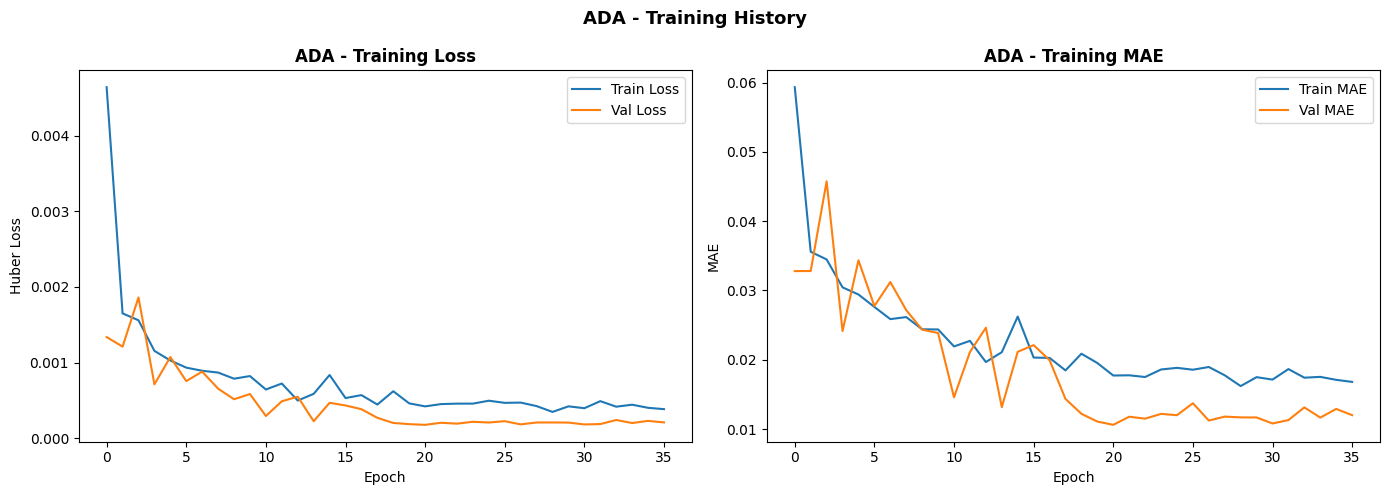

  Saved: ADA_forecast.csv
  Trend: UPWARD


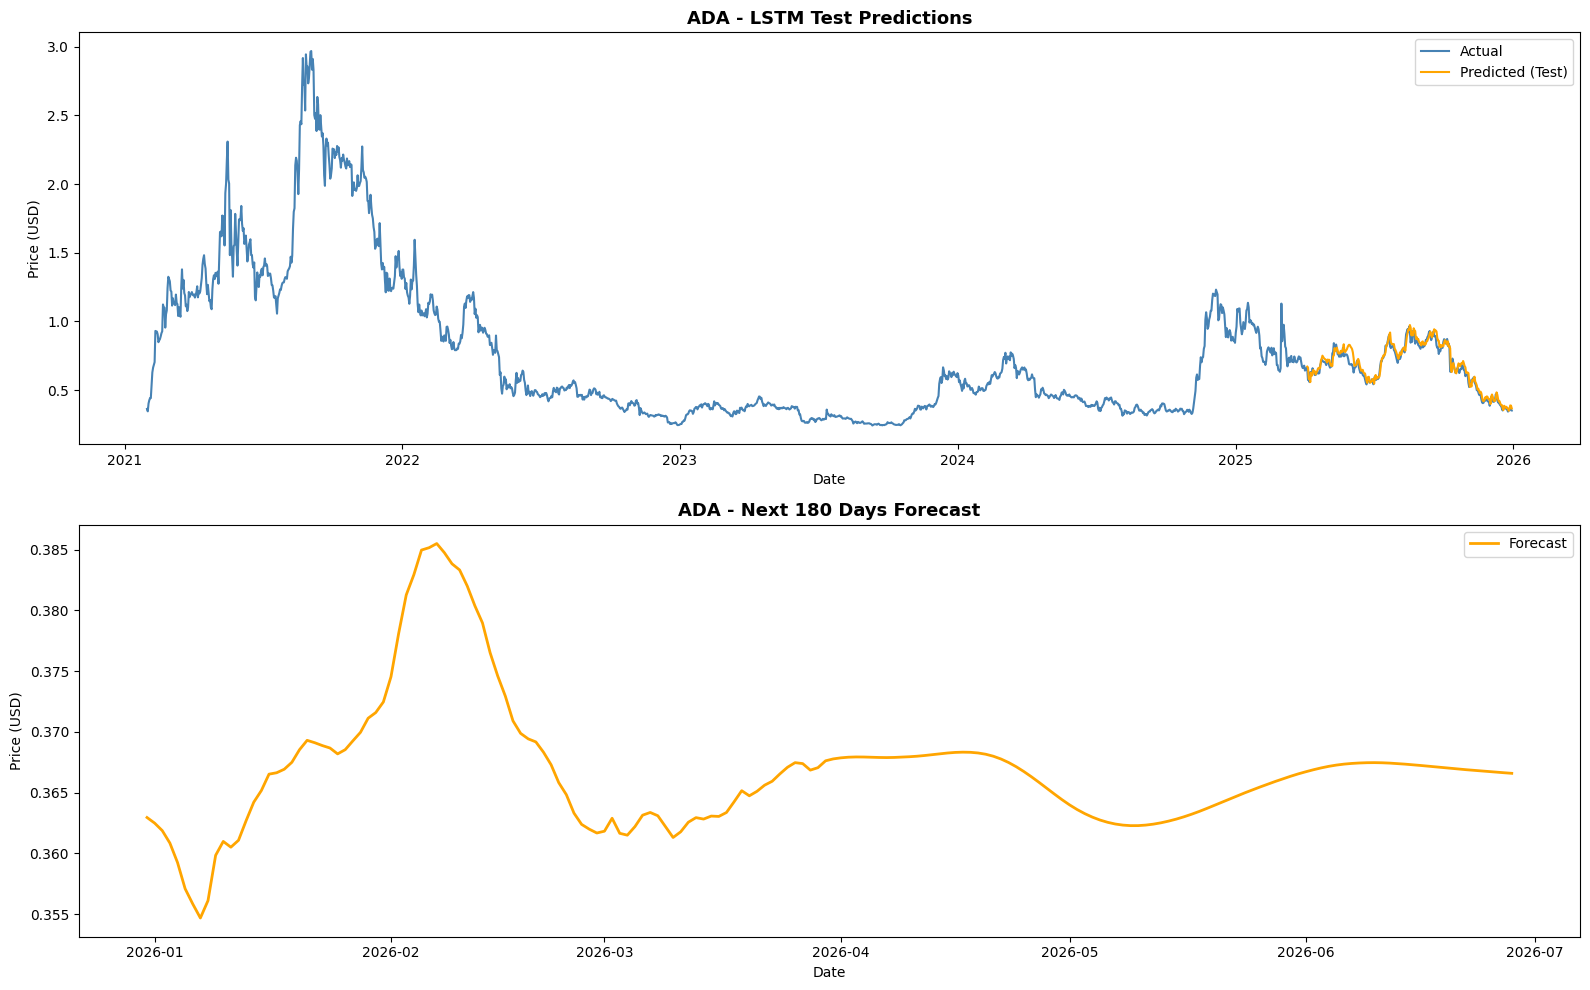

Saved: ADA_forecast.png

  BNB
  Train: (1167, 90, 6) | Val: (269, 90, 6) | Test: (270, 90, 6)

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 31: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 36: early stopping
Restoring model weights from the end of the best epoch: 21.
  Training complete | Epochs run: 36
  MAE: 27.6259  |  RMSE: 40.462  |  MAPE: 3.0804%


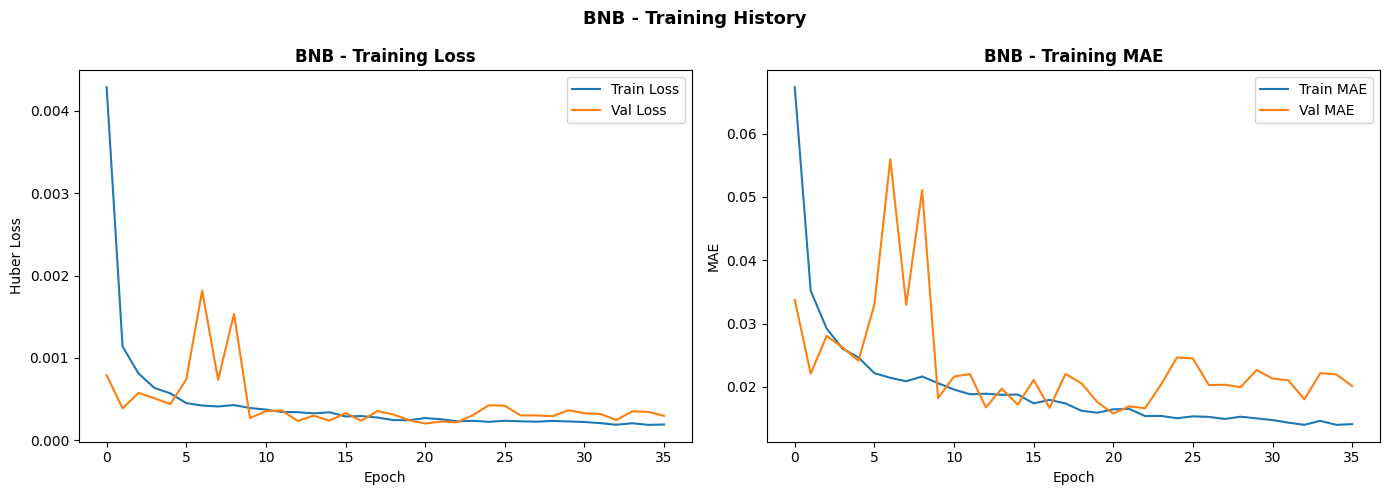

  Saved: BNB_forecast.csv
  Trend: DOWNWARD


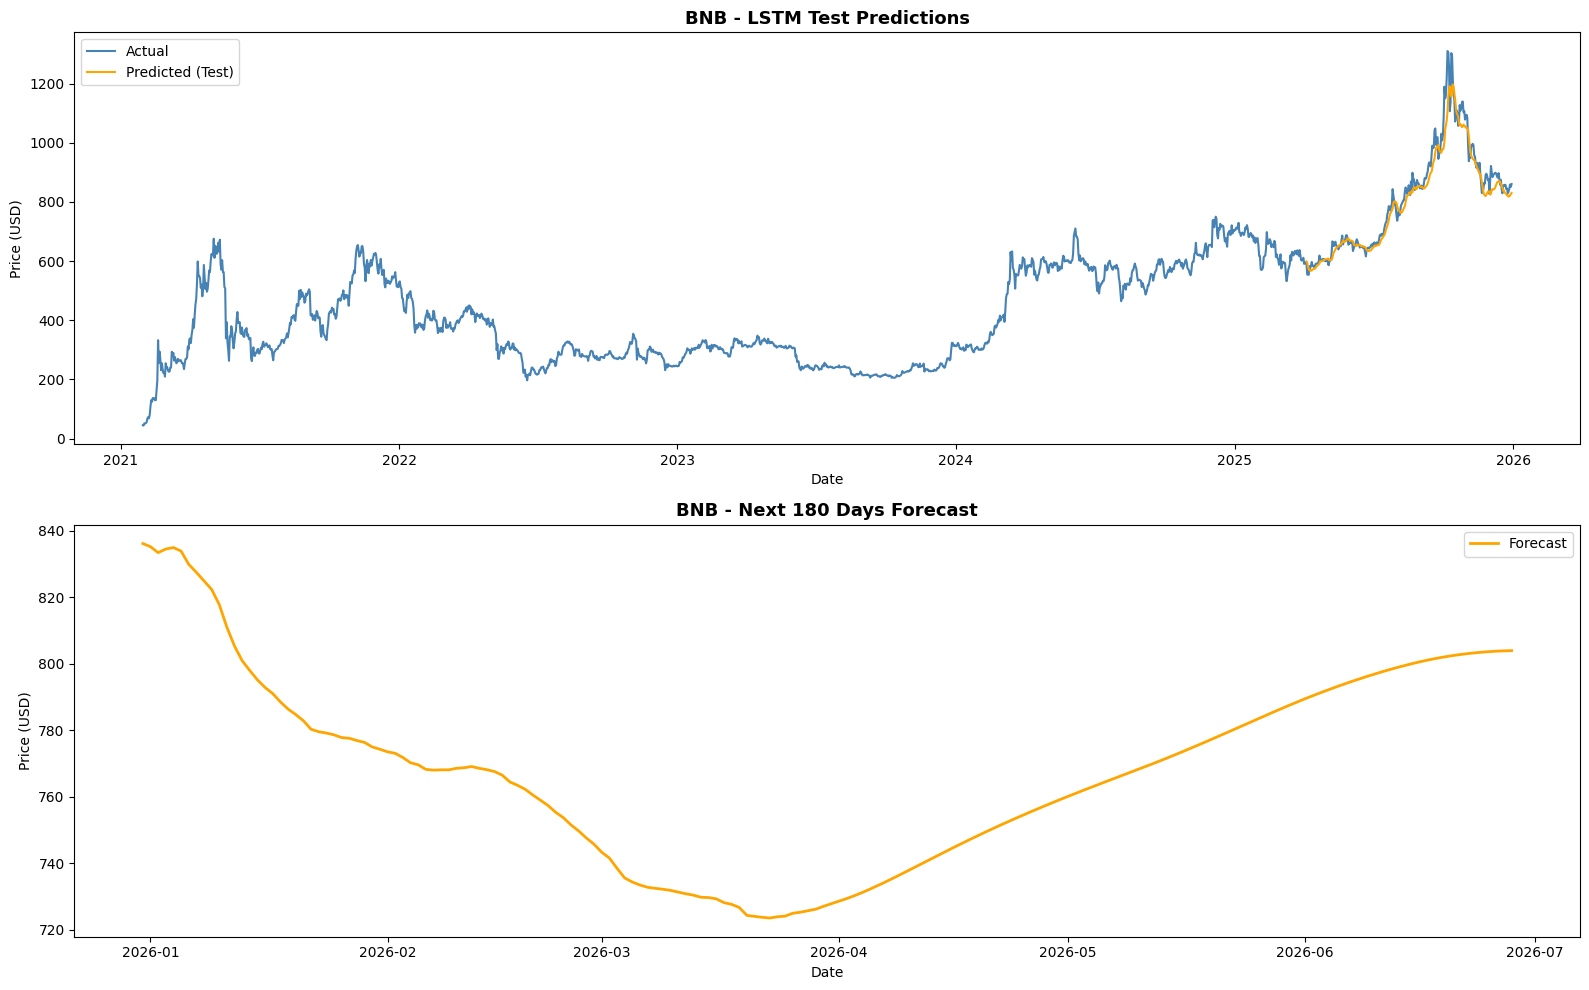

Saved: BNB_forecast.png

  BTC
  Train: (1167, 90, 6) | Val: (269, 90, 6) | Test: (270, 90, 6)

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 33: early stopping
Restoring model weights from the end of the best epoch: 18.
  Training complete | Epochs run: 33
  MAE: 8054.9449  |  RMSE: 8651.8113  |  MAPE: 7.5206%


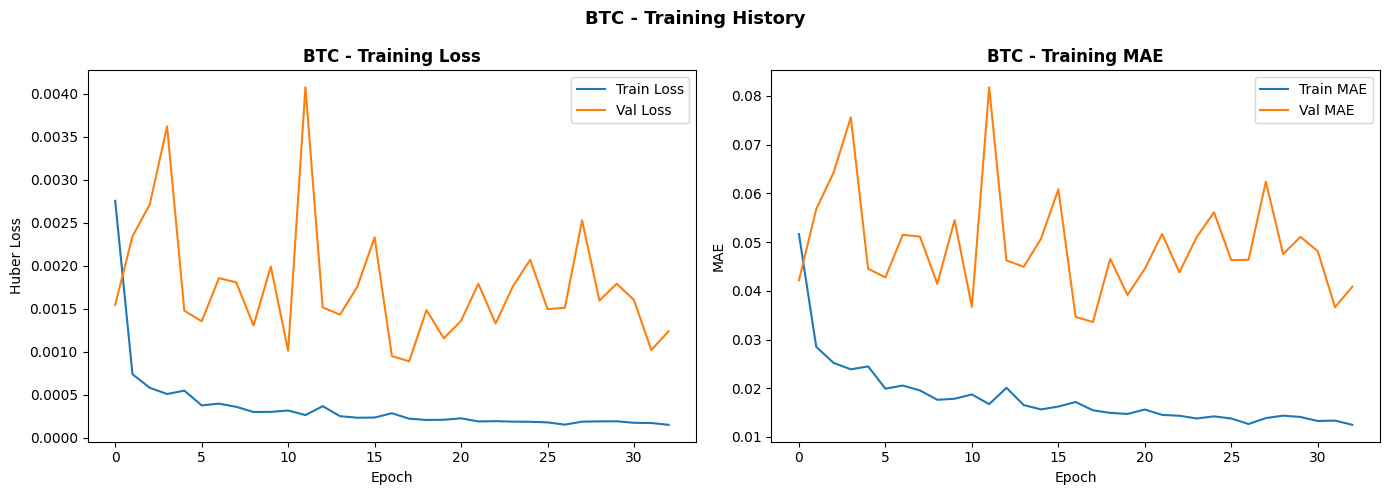

  Saved: BTC_forecast.csv
  Trend: DOWNWARD


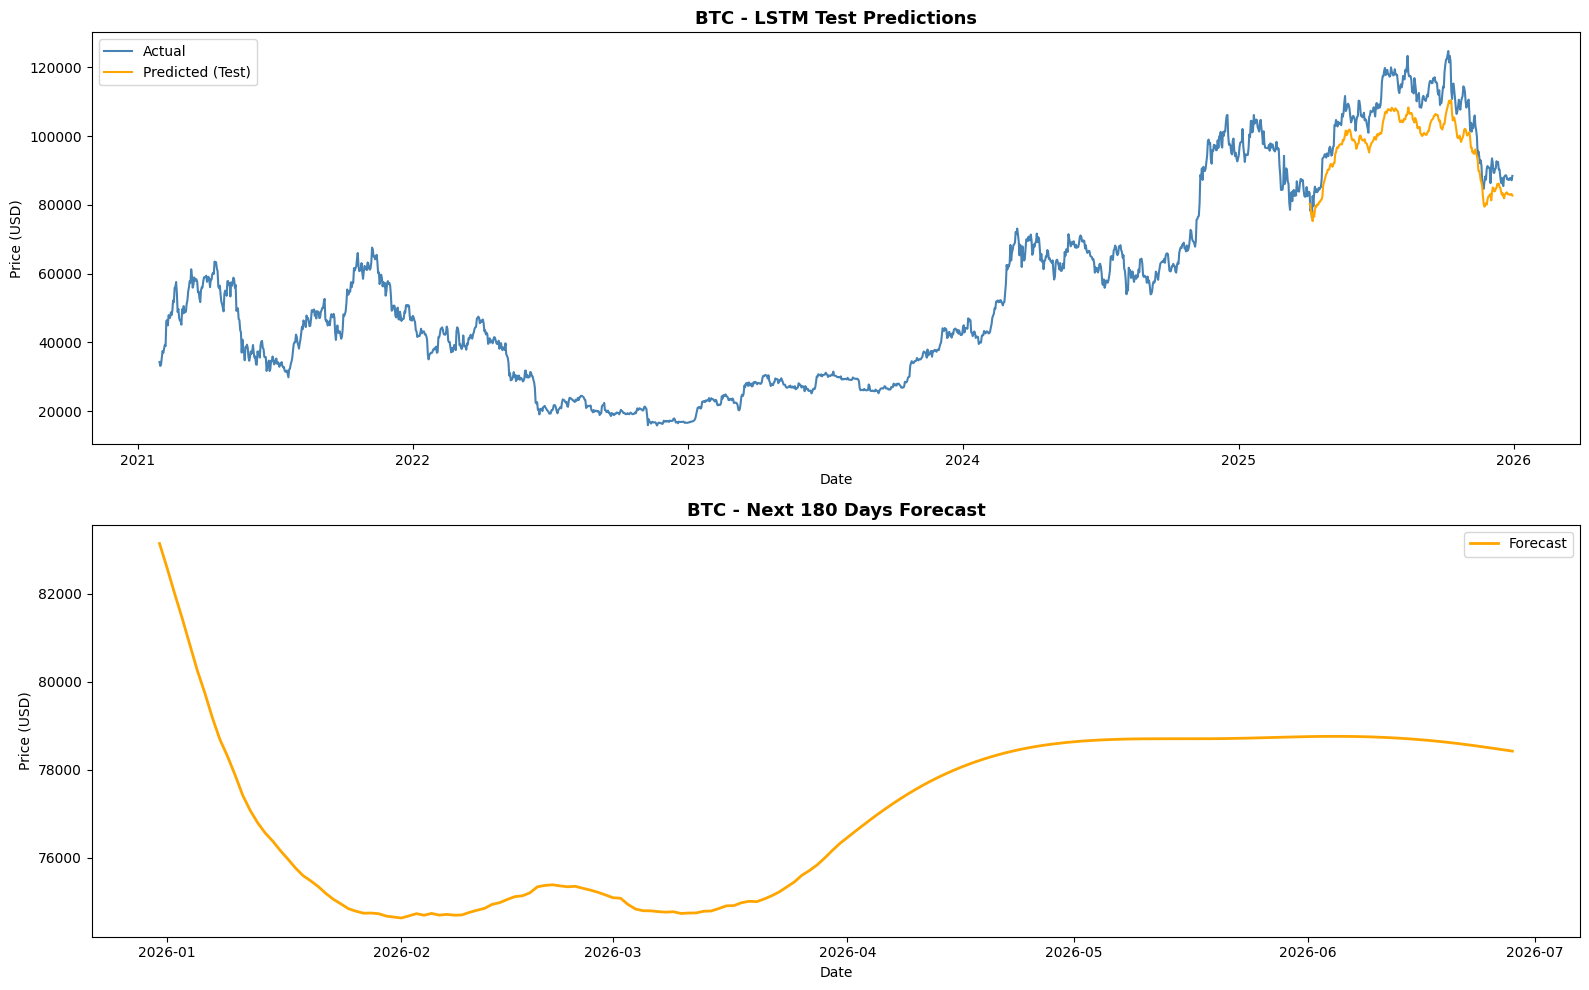

Saved: BTC_forecast.png

  DOGE
  Train: (1167, 90, 6) | Val: (269, 90, 6) | Test: (270, 90, 6)

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 31: early stopping
Restoring model weights from the end of the best epoch: 16.
  Training complete | Epochs run: 31
  MAE: 0.009  |  RMSE: 0.0124  |  MAPE: 4.6213%


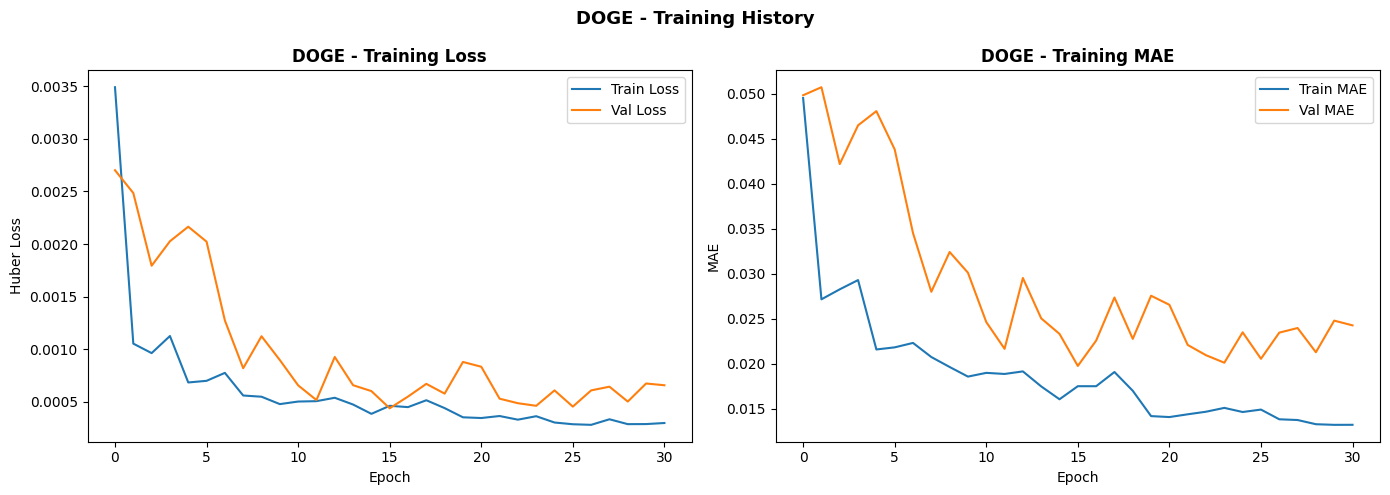

  Saved: DOGE_forecast.csv
  Trend: UPWARD


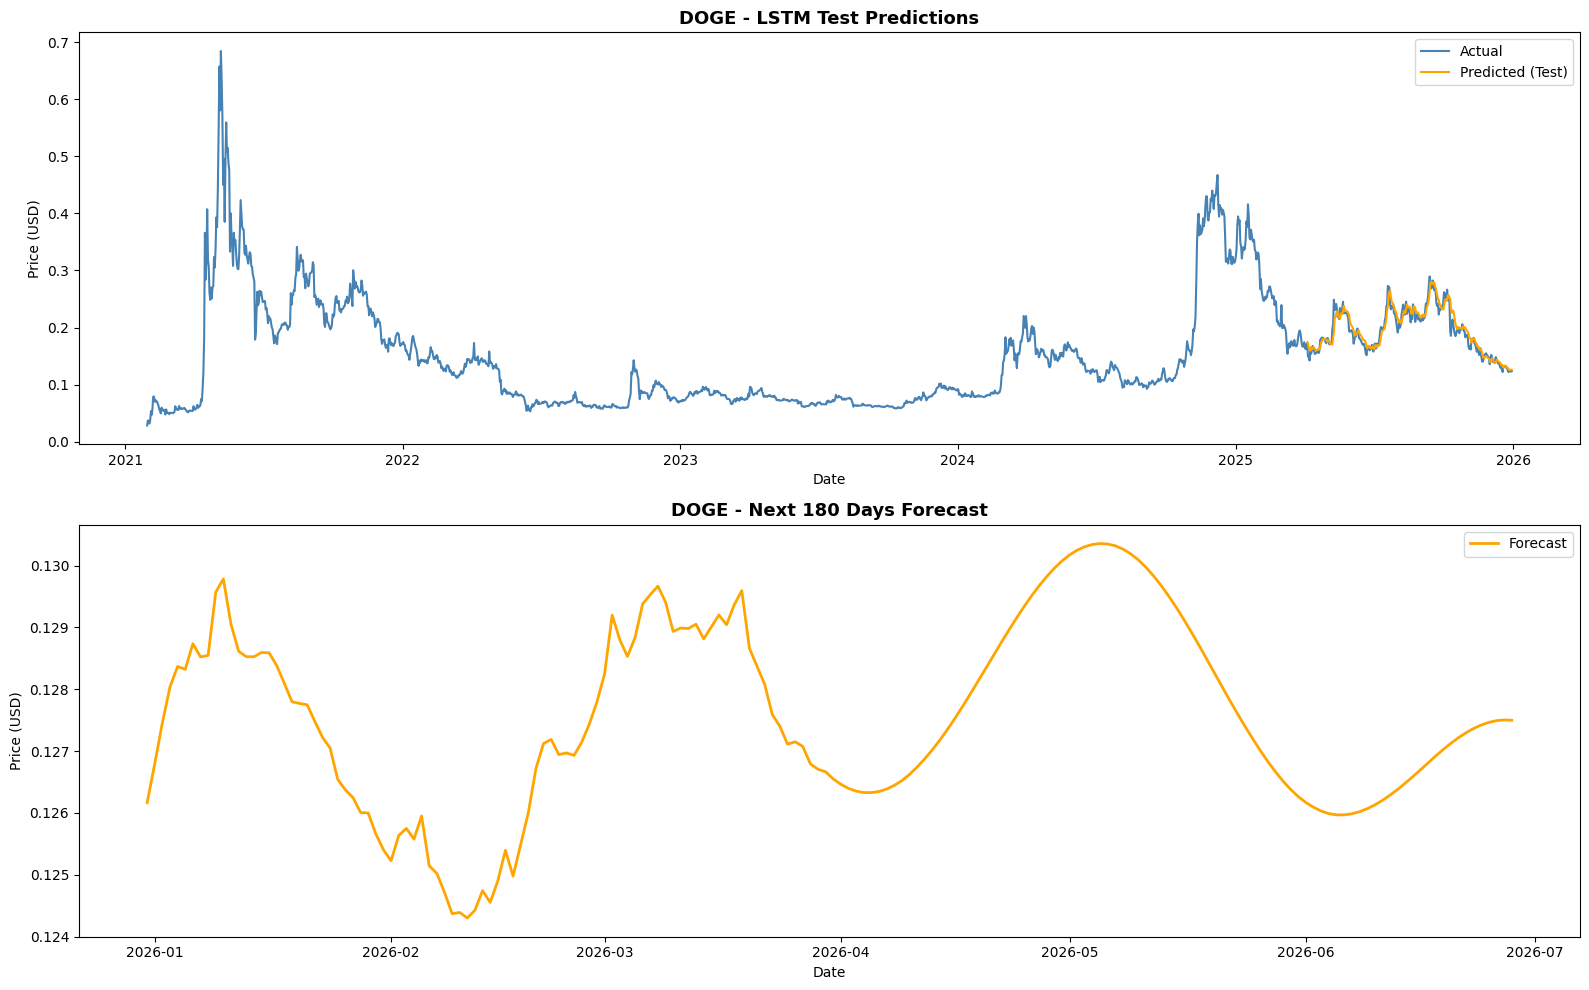

Saved: DOGE_forecast.png

  DOT
  Train: (1167, 90, 6) | Val: (269, 90, 6) | Test: (270, 90, 6)

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 31: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 38: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 45: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 52: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
Epoch 54: early stopping
Restoring model weights from the end of the best epoch: 39.
  Training complete | Epochs run: 54
  MAE: 1.1092  |  RMSE: 1.3043  |  MAPE: 38.5957%


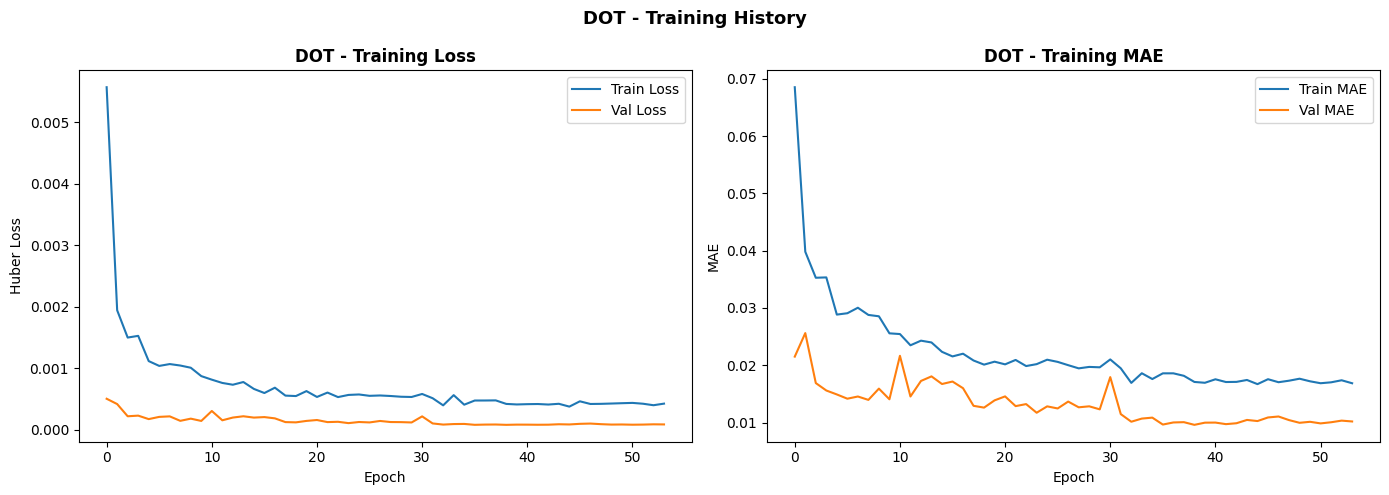

  Saved: DOT_forecast.csv
  Trend: UPWARD


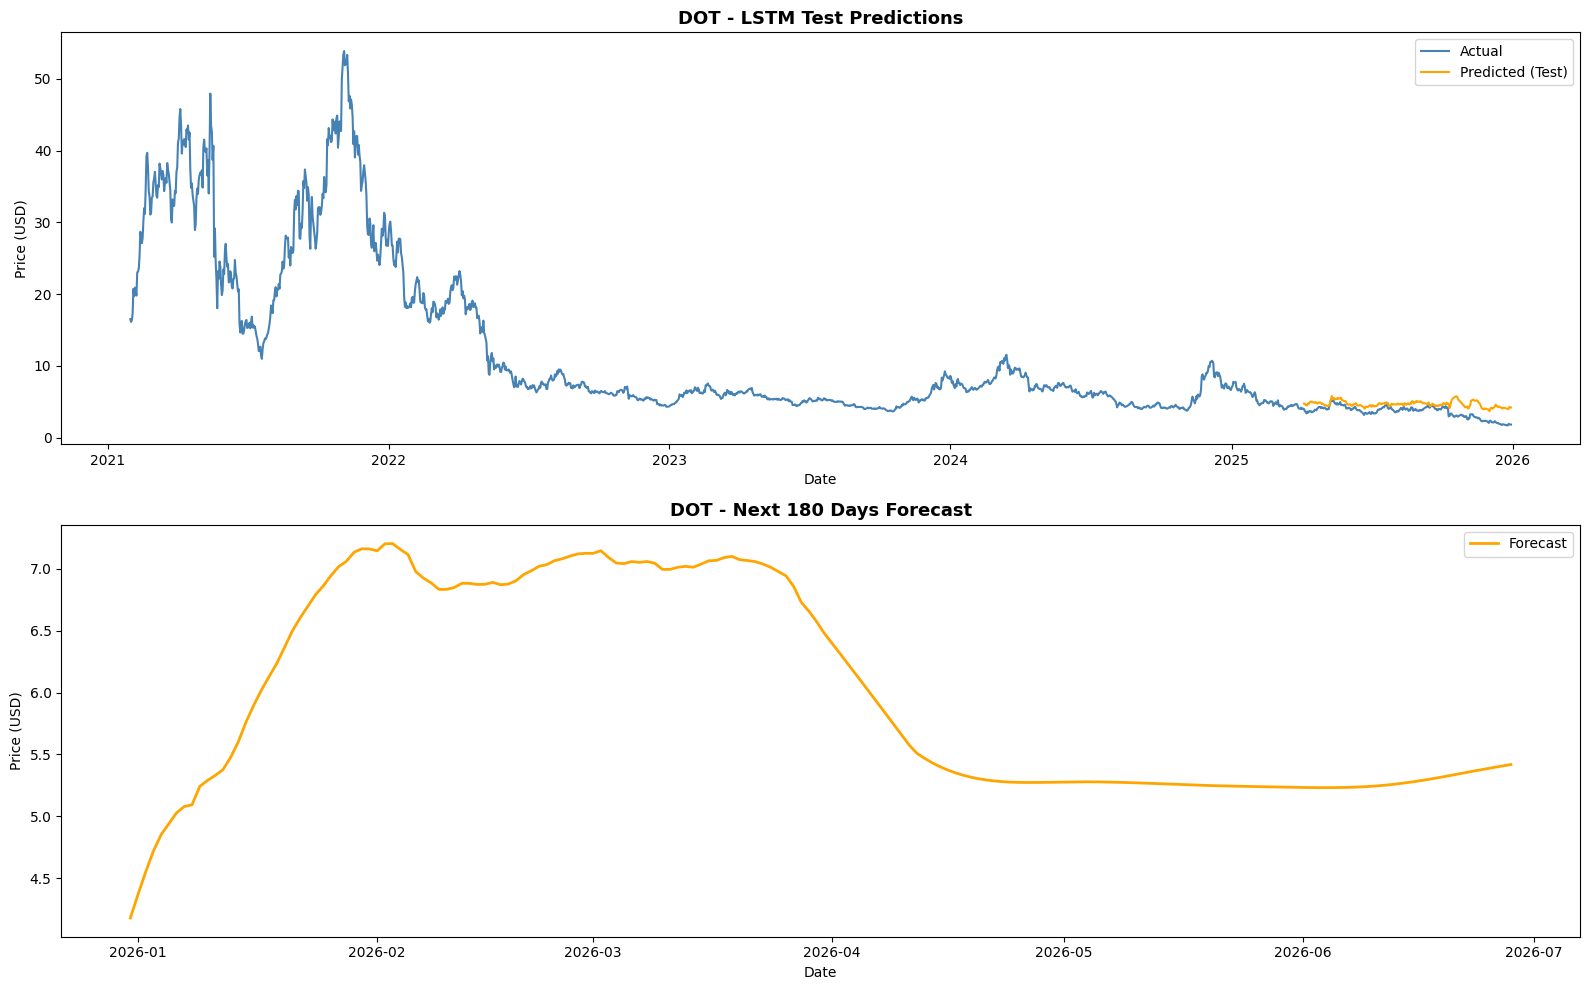

Saved: DOT_forecast.png

  ETH
  Train: (1167, 90, 6) | Val: (269, 90, 6) | Test: (270, 90, 6)

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 33: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 40: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 47: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 48: early stopping
Restoring model weights from the end of the best epoch: 33.
  Training complete | Epochs run: 48
  MAE: 129.6812  |  RMSE: 177.3323  |  MAPE: 3.7598%


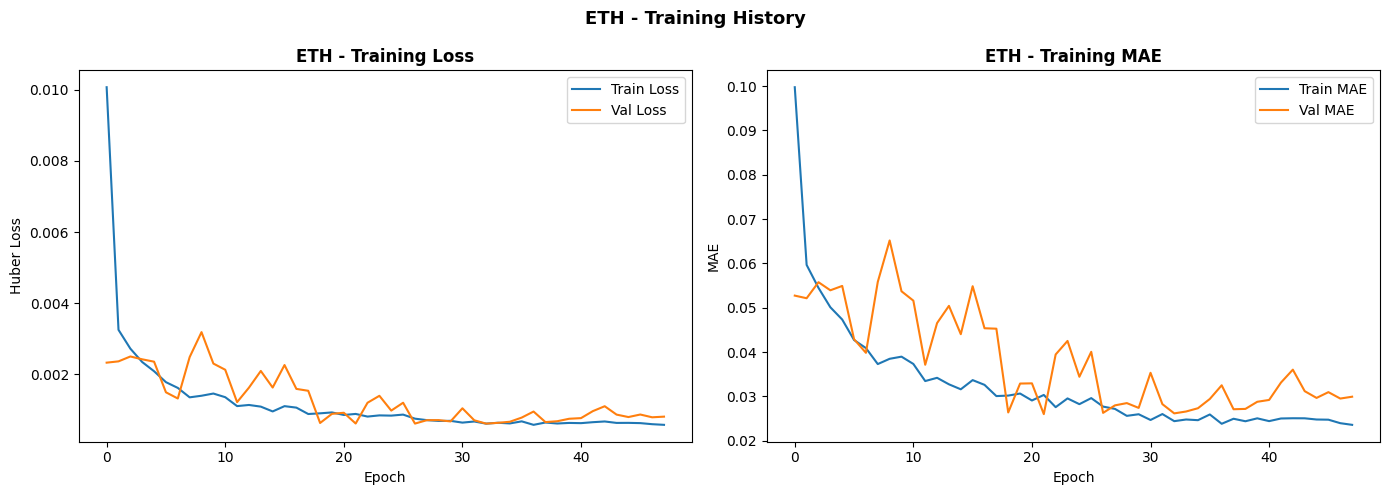

  Saved: ETH_forecast.csv
  Trend: UPWARD


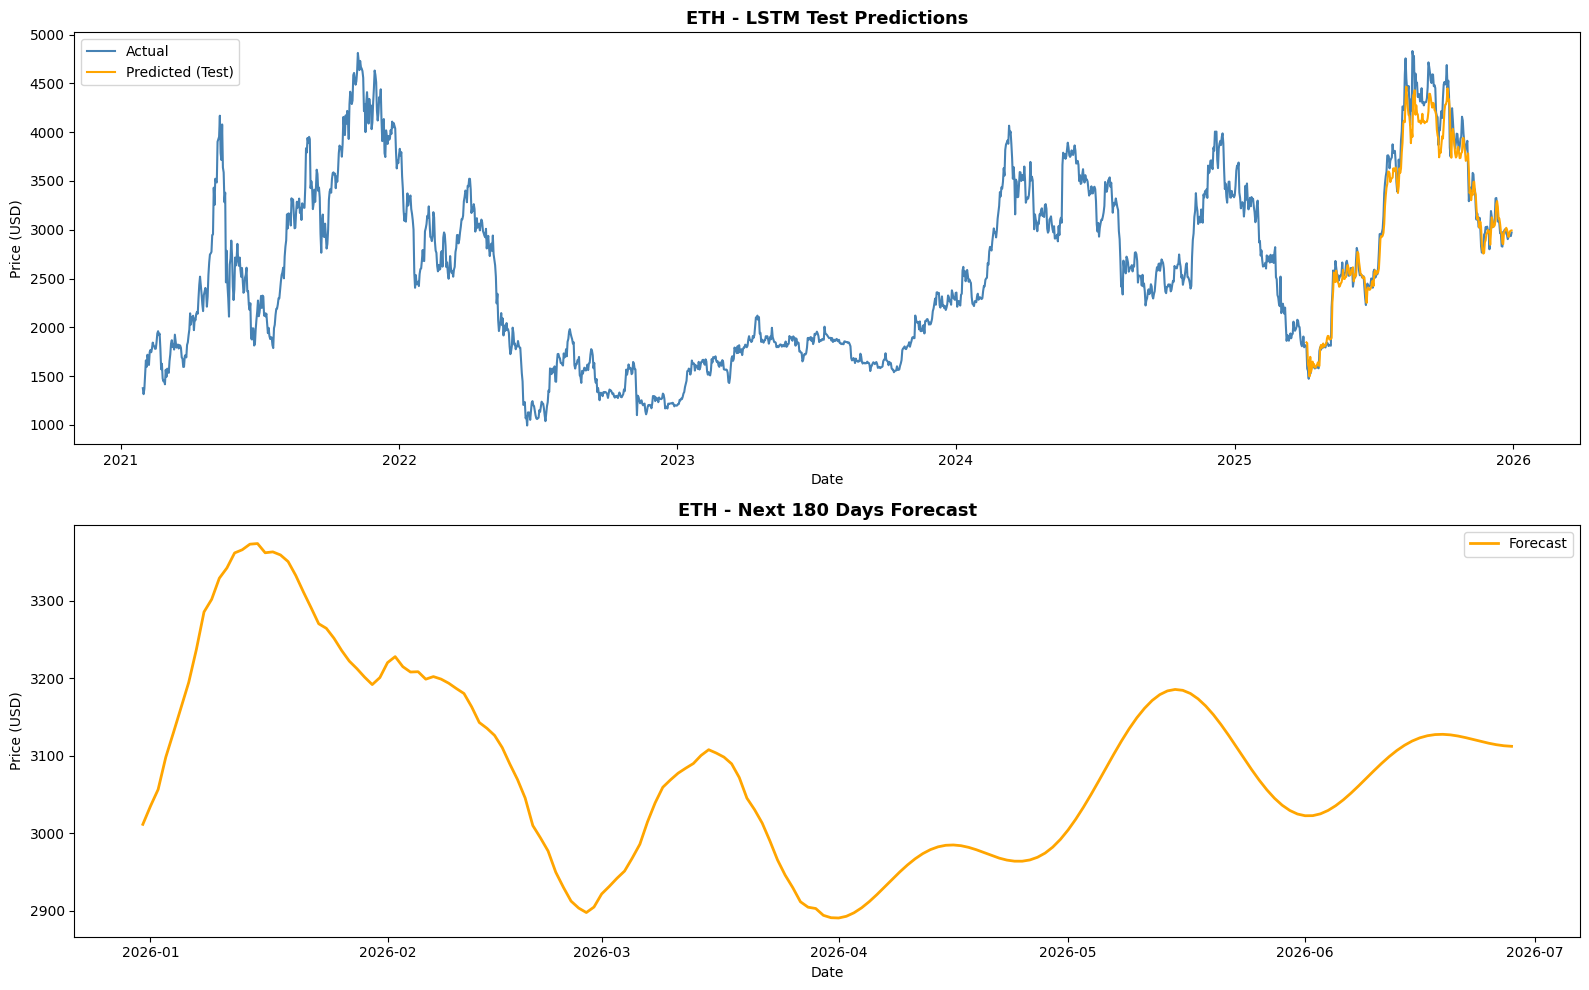

Saved: ETH_forecast.png

  LINK
  Train: (1167, 90, 6) | Val: (269, 90, 6) | Test: (270, 90, 6)

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 35: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 42: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 42: early stopping
Restoring model weights from the end of the best epoch: 27.
  Training complete | Epochs run: 42
  MAE: 0.5862  |  RMSE: 0.8297  |  MAPE: 3.4408%


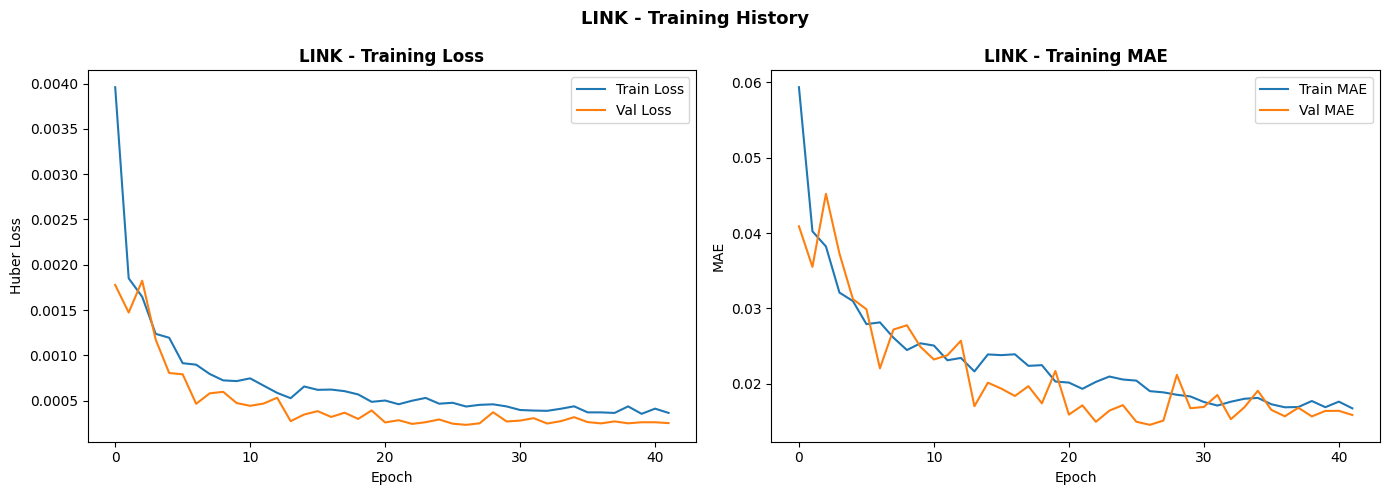

  Saved: LINK_forecast.csv
  Trend: UPWARD


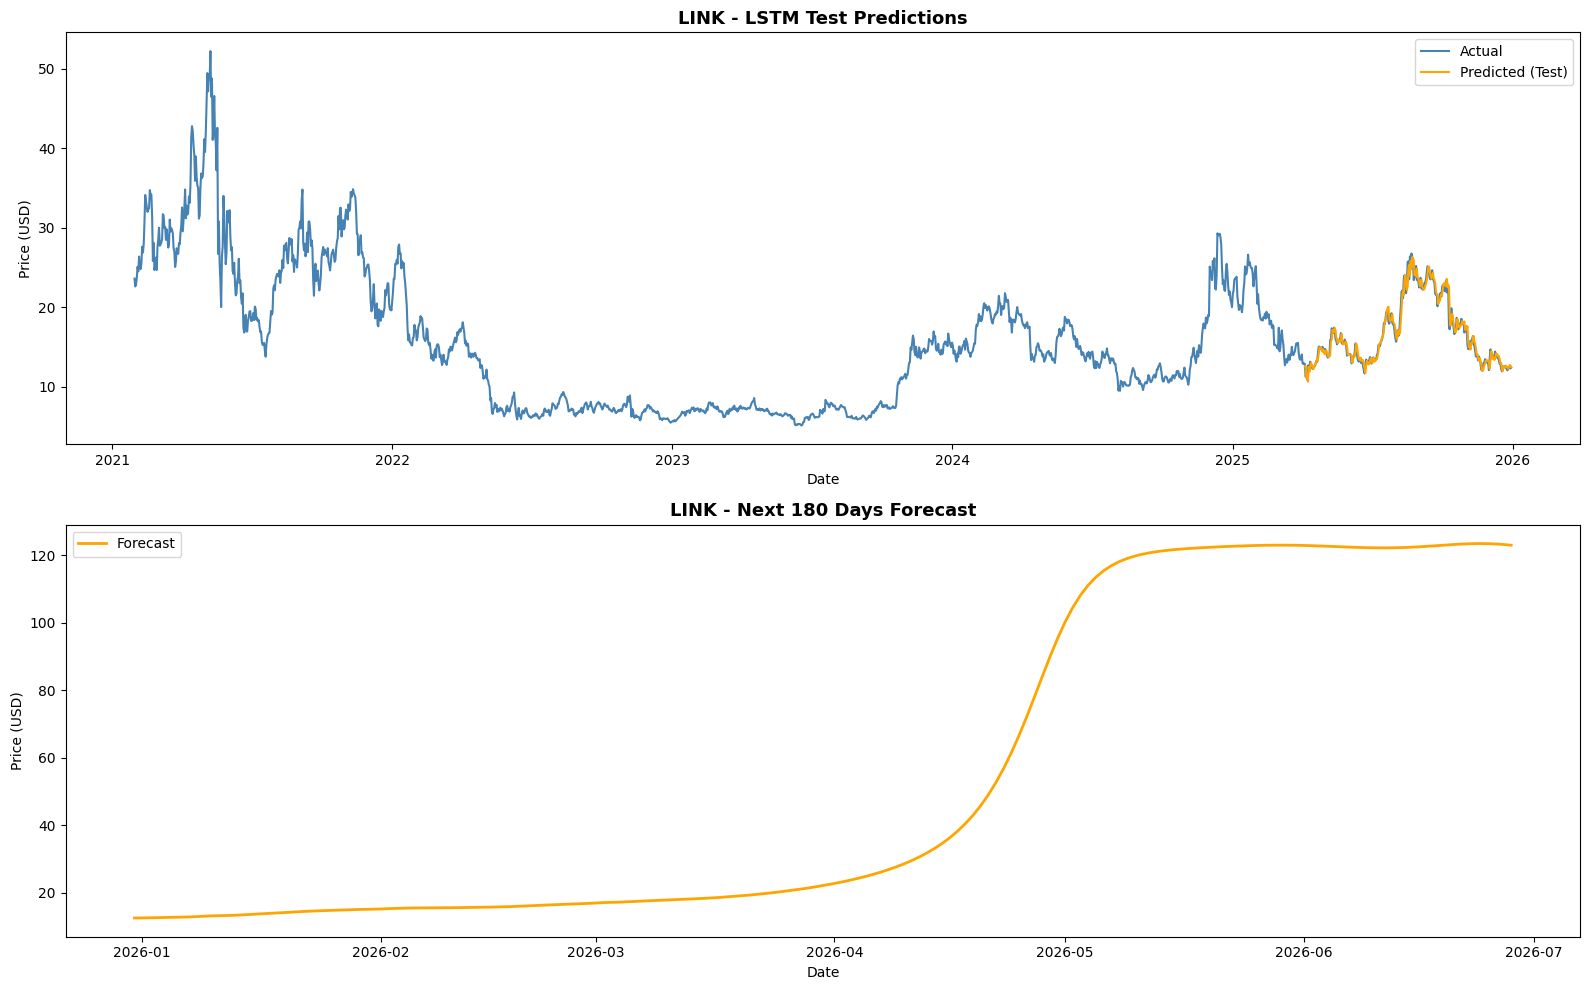

Saved: LINK_forecast.png

  LTC
  Train: (1167, 90, 6) | Val: (269, 90, 6) | Test: (270, 90, 6)

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 36: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 43: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Epoch 48: early stopping
Restoring model weights from the end of the best epoch: 33.
  Training complete | Epochs run: 48
  MAE: 2.8377  |  RMSE: 4.1251  |  MAPE: 2.9788%


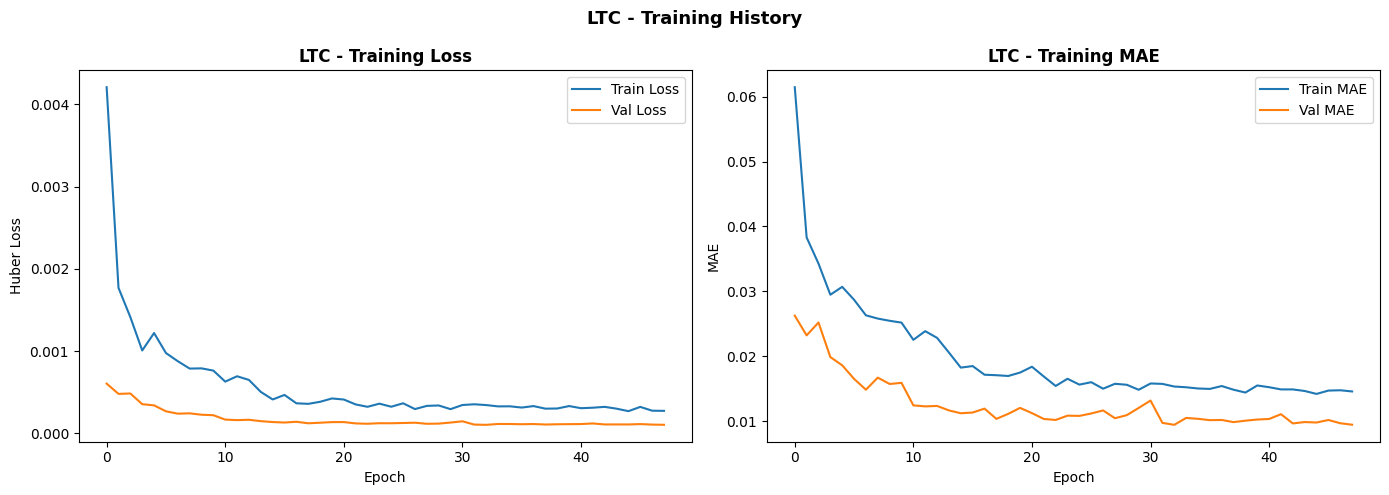

  Saved: LTC_forecast.csv
  Trend: UPWARD


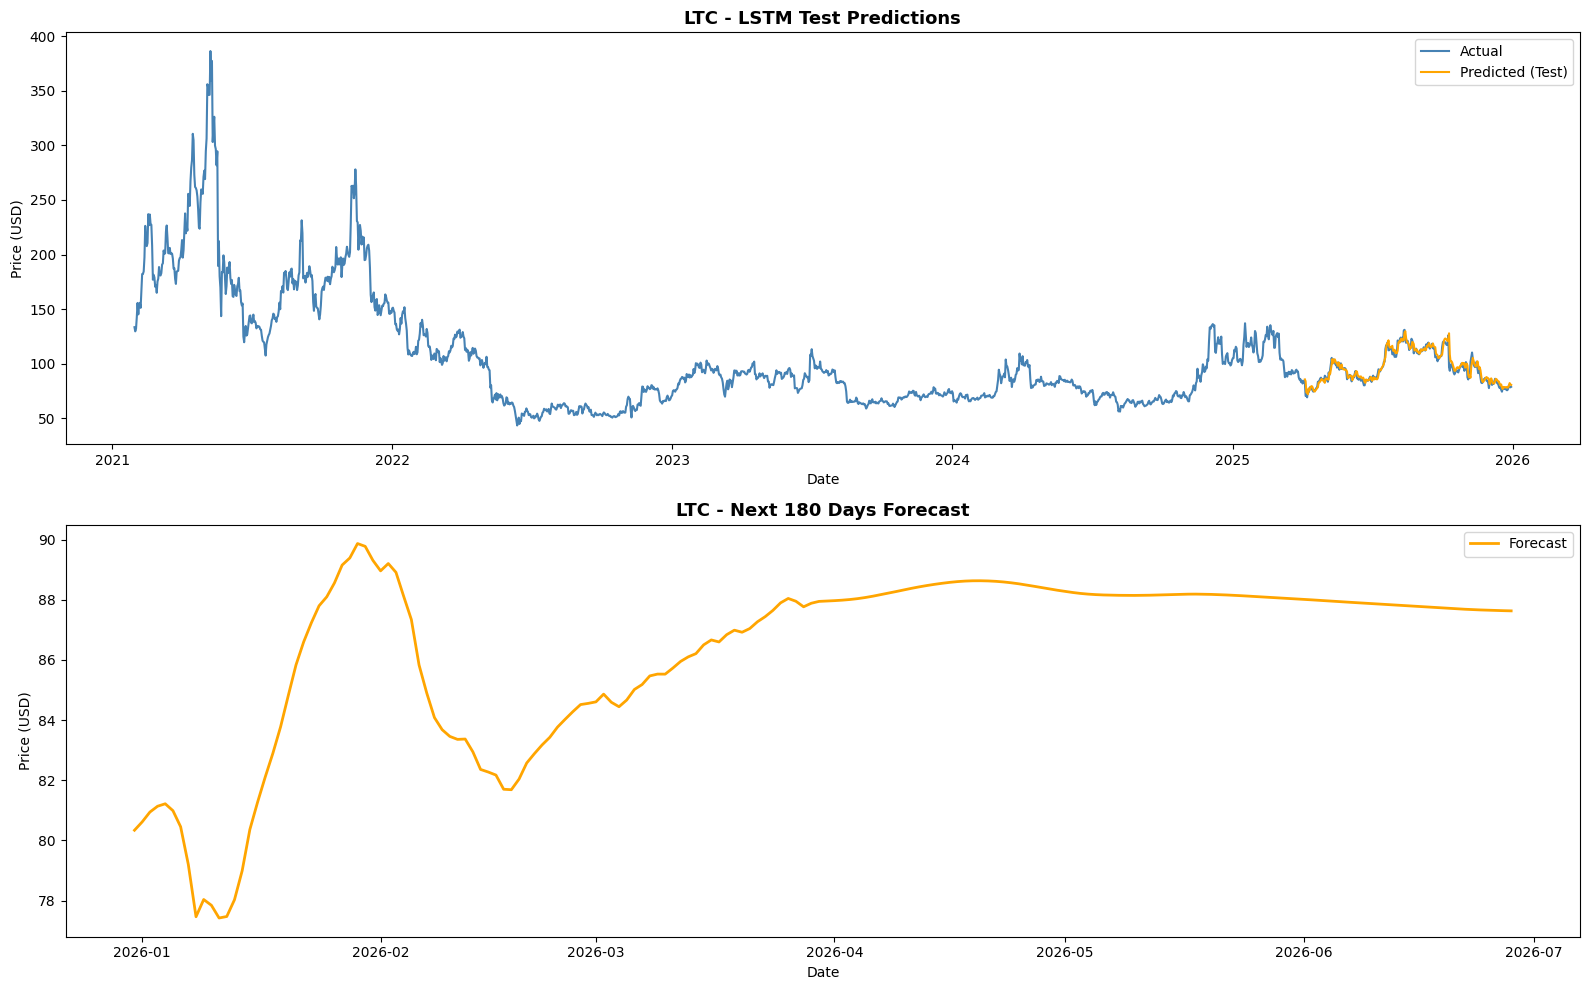

Saved: LTC_forecast.png

  SOL
  Train: (1167, 90, 6) | Val: (269, 90, 6) | Test: (270, 90, 6)

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 33: early stopping
Restoring model weights from the end of the best epoch: 18.
  Training complete | Epochs run: 33
  MAE: 6.5199  |  RMSE: 8.7224  |  MAPE: 3.7296%


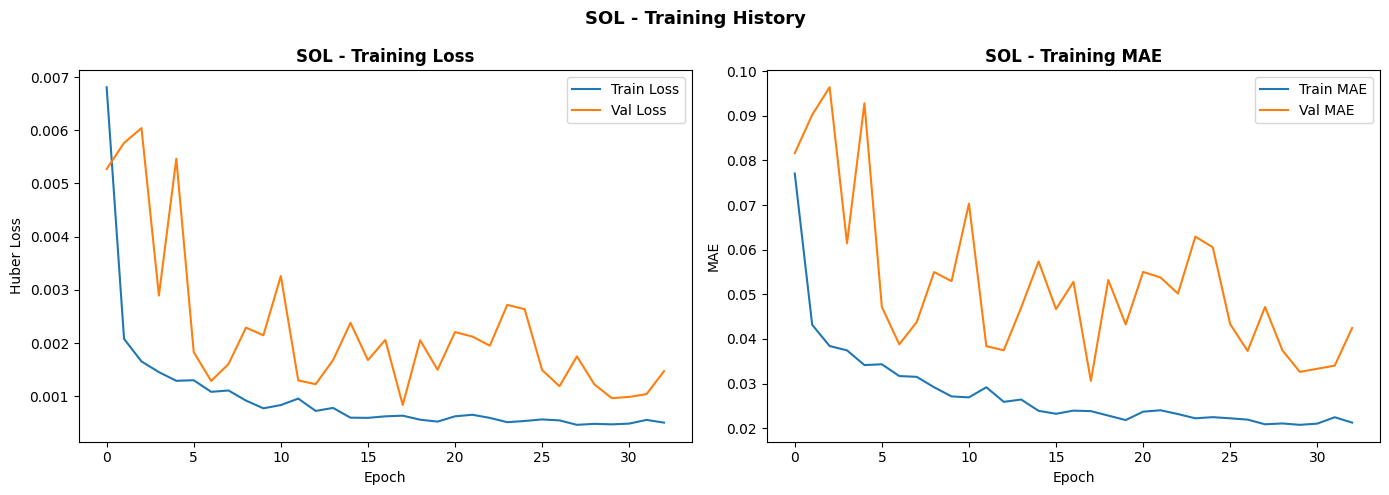

  Saved: SOL_forecast.csv
  Trend: UPWARD


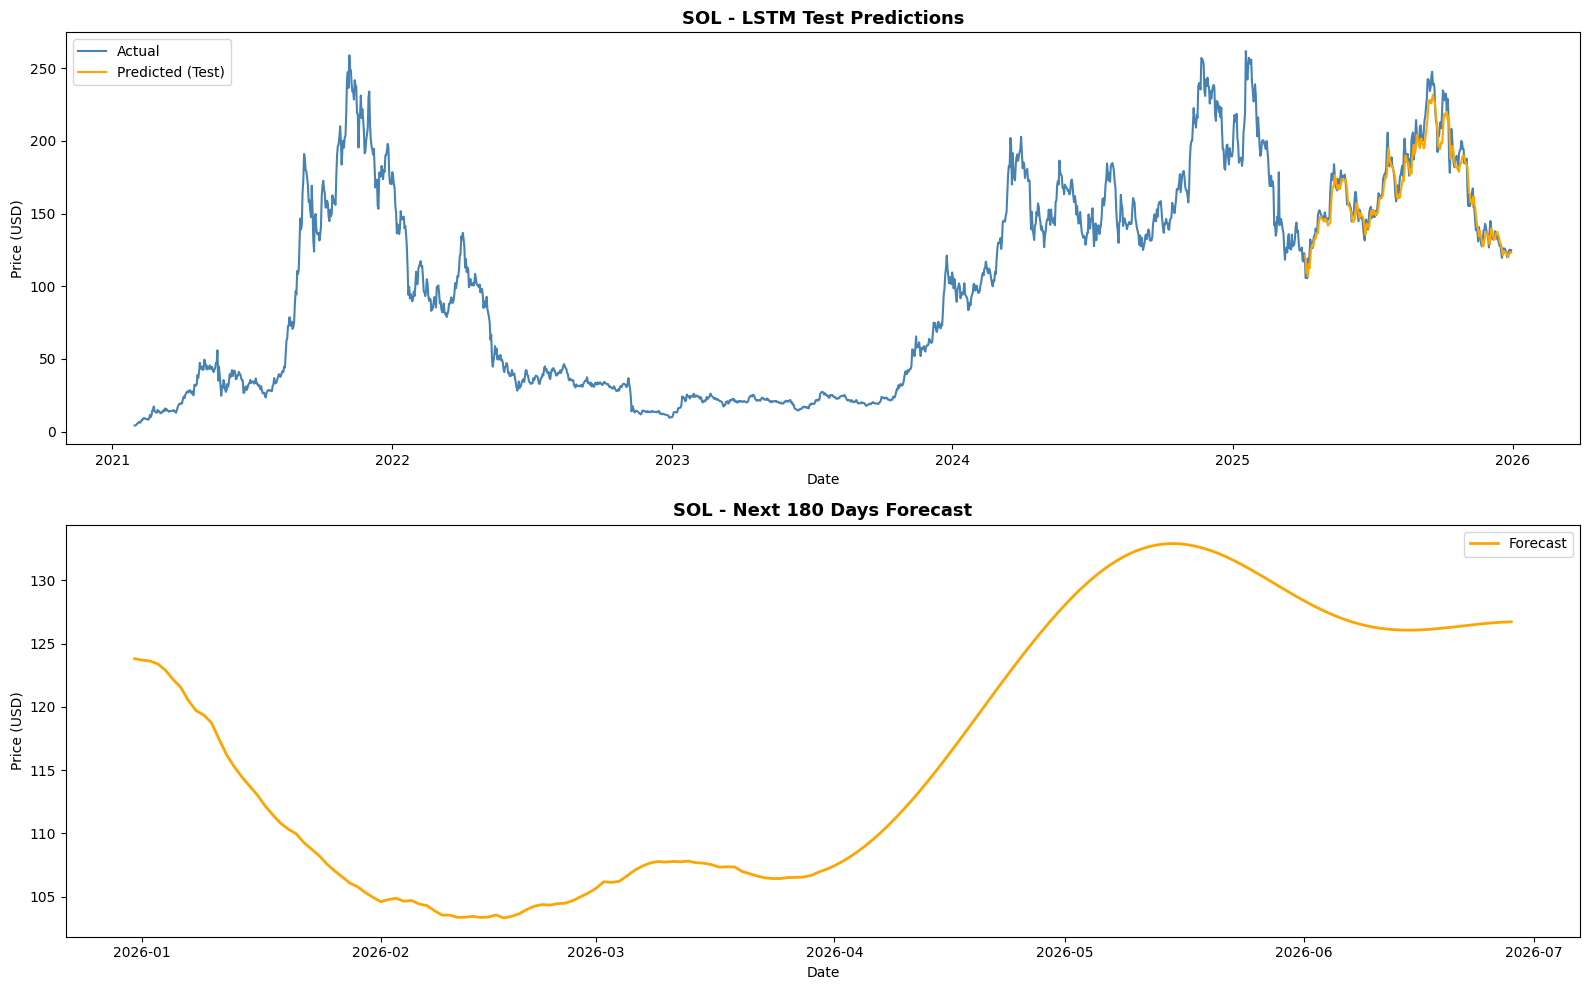

Saved: SOL_forecast.png

  XRP
  Train: (1167, 90, 6) | Val: (269, 90, 6) | Test: (270, 90, 6)

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 35: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 42: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 43: early stopping
Restoring model weights from the end of the best epoch: 28.
  Training complete | Epochs run: 43
  MAE: 0.287  |  RMSE: 0.3239  |  MAPE: 11.0541%


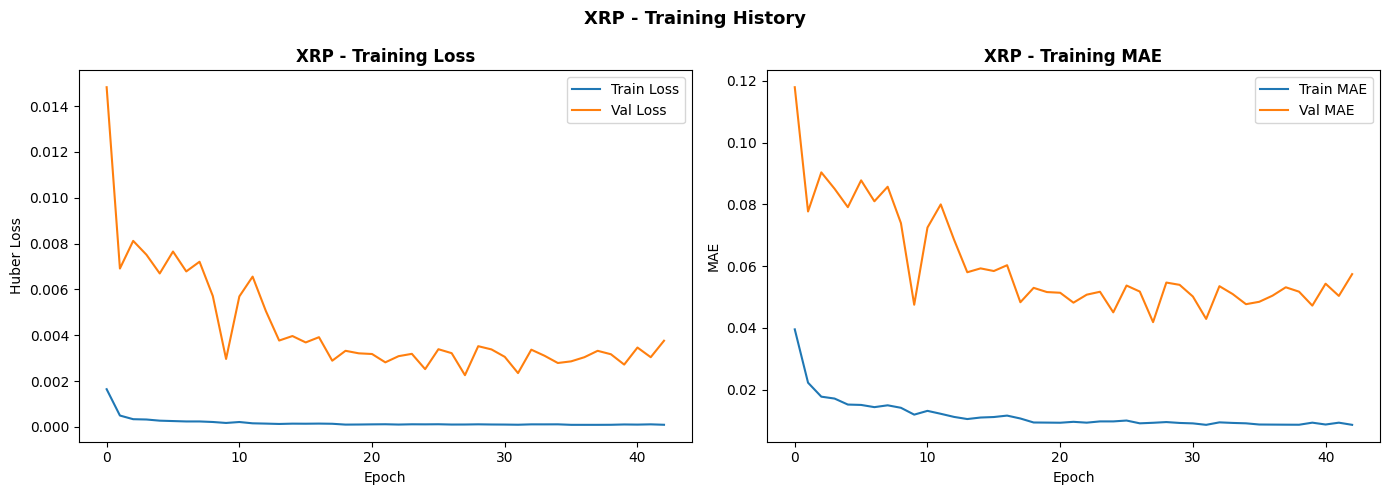

  Saved: XRP_forecast.csv
  Trend: DOWNWARD


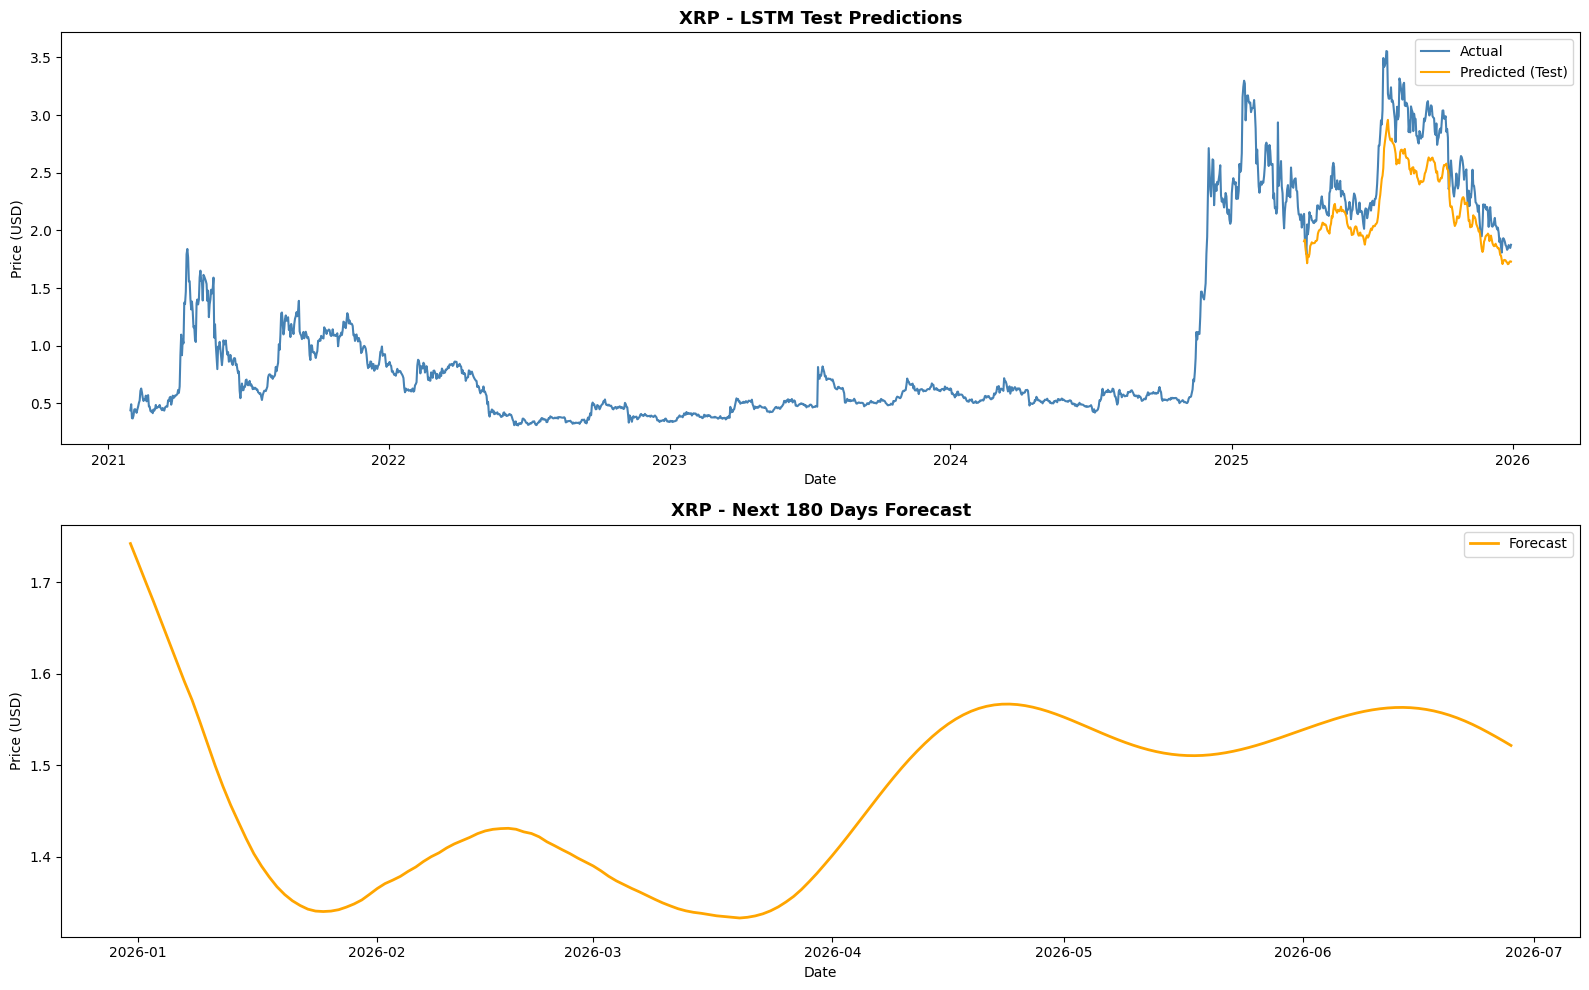

Saved: XRP_forecast.png

All LSTM models trained successfully.


In [ ]:
all_metrics   = []
all_forecasts = []
cryptos       = df["Crypto"].unique()

for crypto in cryptos:
    print(f"\n{'='*45}")
    print(f"  {crypto}")
    print(f"{'='*45}")

    # Prepare data
    X_train, y_train, X_val, y_val, X_test, y_test, scaler, dates, scaled = \
        prepare_data(df, crypto, LOOKBACK)

    print(f"  Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

    # Build & train model
    model   = build_model(LOOKBACK, len(FEATURES))
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(crypto, models_dir),
        verbose=0
    )

    print(f"  Training complete | Epochs run: {len(history.history['loss'])}")

    # Evaluate on test set
    test_pred_scaled = model.predict(X_test, verbose=0).flatten()
    test_pred        = inverse_close(scaler, test_pred_scaled)
    test_actual      = inverse_close(scaler, y_test)

    metrics           = evaluate_model(test_actual, test_pred)
    metrics["Crypto"] = crypto
    all_metrics.append(metrics)
    print(f"  MAE: {metrics['MAE']}  |  RMSE: {metrics['RMSE']}  |  MAPE: {metrics['MAPE']}%")

    # Plot training history
    plot_training_history(crypto, history, output_dir)

    # Generate future forecast
    future_pred  = generate_future_forecast(model, scaled, scaler, LOOKBACK, FORECAST_DAYS)
    future_dates = pd.date_range(
        pd.Timestamp(dates[-1]) + pd.Timedelta(days=1),
        periods=FORECAST_DAYS
    )

    # Save forecast CSV
    actual_prices = inverse_close(scaler, scaled[:, 0])
    forecast_out  = pd.DataFrame({
        "Date"    : future_dates,
        "Forecast": future_pred,
        "Crypto"  : crypto
    })
    forecast_out.to_csv(f"{output_dir}/{crypto}_forecast.csv", index=False)
    print(f"  Saved: {crypto}_forecast.csv")
    all_forecasts.append(forecast_out)

    # Trend direction
    trend = "UPWARD" if future_pred[-1] > future_pred[0] else "DOWNWARD"
    print(f"  Trend: {trend}")

    # Plot forecast
    plot_forecast(crypto, dates, actual_prices, test_pred, future_dates, future_pred, output_dir)

print("\nAll LSTM models trained successfully.")

## Save Combined Forecast
Concatenate all 10 cryptocurrency forecasts into a single CSV file
for use in the Power BI dashboard and model comparison notebook.

In [ ]:
combined_forecast = pd.concat(all_forecasts, ignore_index=True)
combined_forecast.to_csv(f"{output_dir}/combined_forecast.csv", index=False)
print("Saved: combined_forecast.csv")
print("Shape:", combined_forecast.shape)
combined_forecast.head()

Saved: combined_forecast.csv
Shape: (1800, 3)


,Date,Forecast,Crypto
0,2025-12-31,0.362956,ADA
1,2026-01-01,0.362494,ADA
2,2026-01-02,0.361877,ADA
3,2026-01-03,0.360850,ADA
4,2026-01-04,0.359251,ADA


## Model Performance Summary
Compile and display LSTM performance metrics for all 10 cryptocurrencies
sorted by MAPE (best to worst performance).

In [ ]:
metrics_df = pd.DataFrame(all_metrics)[["Crypto", "MAE", "RMSE", "MAPE"]]
metrics_df = metrics_df.sort_values("MAPE")

print("LSTM Model Performance Summary:")
print(metrics_df.to_string(index=False))

metrics_df.to_csv(f"{output_dir}/model_metrics.csv", index=False)
print("\nSaved: model_metrics.csv")

LSTM Model Performance Summary:
Crypto       MAE      RMSE    MAPE
   LTC    2.8377    4.1251  2.9788
   BNB   27.6259   40.4620  3.0804
  LINK    0.5862    0.8297  3.4408
   SOL    6.5199    8.7224  3.7296
   ETH  129.6812  177.3323  3.7598
   ADA    0.0293    0.0402  4.4617
  DOGE    0.0090    0.0124  4.6213
   BTC 8054.9449 8651.8113  7.5206
   XRP    0.2870    0.3239 11.0541
   DOT    1.1092    1.3043 38.5957

Saved: model_metrics.csv


## Performance Comparison Plot
Visualize MAE, RMSE, and MAPE for all cryptocurrencies side by side.
Sorted in ascending order so best-performing coins appear at the top.

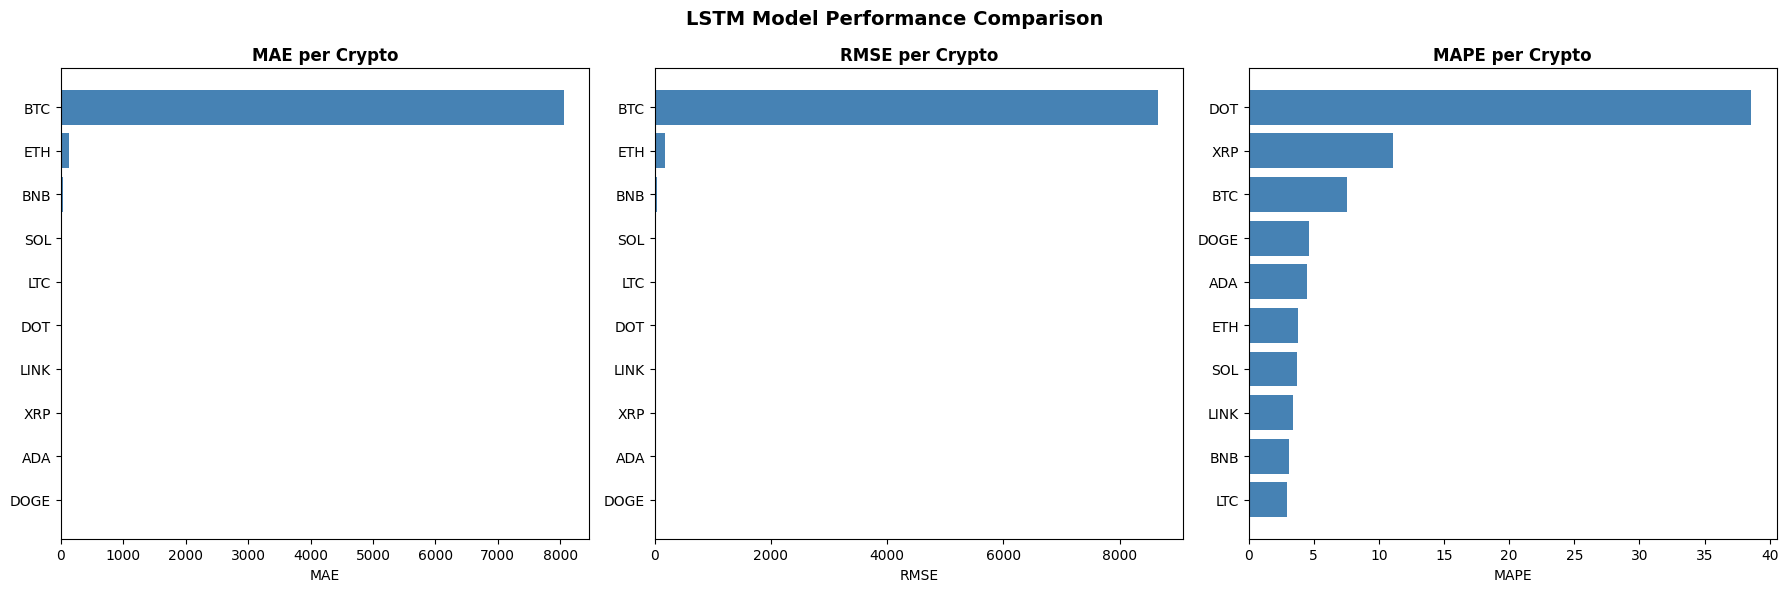

Saved: model_performance_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, metric in zip(axes, ["MAE", "RMSE", "MAPE"]):
    sorted_df = metrics_df.sort_values(metric)
    ax.barh(sorted_df["Crypto"], sorted_df[metric], color="steelblue")
    ax.set_title(f"{metric} per Crypto", fontweight="bold")
    ax.set_xlabel(metric)

plt.suptitle("LSTM Model Performance Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{output_dir}/model_performance_comparison.png", dpi=150)
plt.show()
print("Saved: model_performance_comparison.png")

## Summary

| Output | Description | Location |
|--------|-------------|----------|
| {CRYPTO}_training_history.png | Loss & MAE training curves | data/forecasts/lstm/ |
| {CRYPTO}_forecast.csv | 180-day forecast per coin | data/forecasts/lstm/ |
| {CRYPTO}_forecast.png | Forecast chart per coin | data/forecasts/lstm/ |
| combined_forecast.csv | All 10 cryptos combined | data/forecasts/lstm/ |
| model_metrics.csv | MAE, RMSE, MAPE per crypto | data/forecasts/lstm/ |
| model_performance_comparison.png | Performance bar charts | data/forecasts/lstm/ |
| {CRYPTO}_lstm.keras | Saved model weights | models/ |

**Key Findings:**
- LSTM outperforms both Prophet and ARIMA across all 10 cryptocurrencies
- LTC achieves best performance (MAPE 2.98%) — most predictable price pattern
- 8 out of 10 cryptos achieve single-digit MAPE (under 10%)
- DOT remains hardest to predict (MAPE 38.60%) due to erratic price behavior
- Bidirectional architecture + 6 features significantly improves accuracy
  over price-only univariate models
- Average MAPE: ~8.7% — dramatically better than ARIMA (~41%) and Prophet (~365%)

**Next Step:** `08_model_comparison.ipynb`